VGGNet

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Image parameters
img_size = (224, 224)
batch_size = 16

In [4]:
# Data paths
train_dir = r'small_dataset\asl_alphabet_train'
test_dir = r'small_dataset\asl_alphabet_test'

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', subset='training')

val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', subset='validation')

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

Found 32360 images belonging to 36 classes.
Found 8080 images belonging to 36 classes.
Found 36 images belonging to 36 classes.


In [31]:
# Load VGG-16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False  # Freeze layers

# Add custom layers
global_avg = Flatten()(base_model.output)
dense1 = Dense(512, activation='relu')(global_avg)
dropout1 = Dropout(0.5)(dense1)
dense2 = Dense(256, activation='relu')(dropout1)
dropout2 = Dropout(0.5)(dense2)
out_layer = Dense(len(train_generator.class_indices), activation='softmax')(dropout2)
model = Model(inputs=base_model.input, outputs=out_layer)

In [32]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# # Train model
# history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# # Save model
# model.save('asl_vgg_model.h5')

In [ ]:
# from tensorflow.keras.models import load_model

# # Load the previously saved model
# model = load_model('asl_vgg_model_1.h5')

In [8]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Evaluate the model on the validation/test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8698 - loss: 0.6377
Test Accuracy: 0.8333
Test Loss: 0.6958


In [ ]:
# import matplotlib.pyplot as plt

# # Extract values
# acc = history.history['accuracy']
# val_acc = history.history['val_accuracy']
# loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(1, len(acc) + 1)

# # Plot Accuracy
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(epochs, acc, label='Training Accuracy')
# plt.plot(epochs, val_acc, label='Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Training & Validation Accuracy')
# plt.legend()

# # Plot Loss
# plt.subplot(1, 2, 2)
# plt.plot(epochs, loss, label='Training Loss')
# plt.plot(epochs, val_loss, label='Validation Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training & Validation Loss')
# plt.legend()

# plt.show()

AttributeError: 'Functional' object has no attribute 'history'

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get class labels
class_labels = list(test_generator.class_indices.keys())

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         1
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         1
           A       0.00      0.00      0.00         1
           B       1.00      1.00      1.00         1
           C       1.00      1.00      1.00         1
           D       0.50      1.00      0.67         1
           E       0.33      1.00      0.50         1
           F       1.00      1.00      1.00         1
           G       1.0

d:\Feby\MTech Amrita\Sem 2\XAI\Project\ASL\asl_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Feby\MTech Amrita\Sem 2\XAI\Project\ASL\asl_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Feby\MTech Amrita\Sem 2\XAI\Project\ASL\asl_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

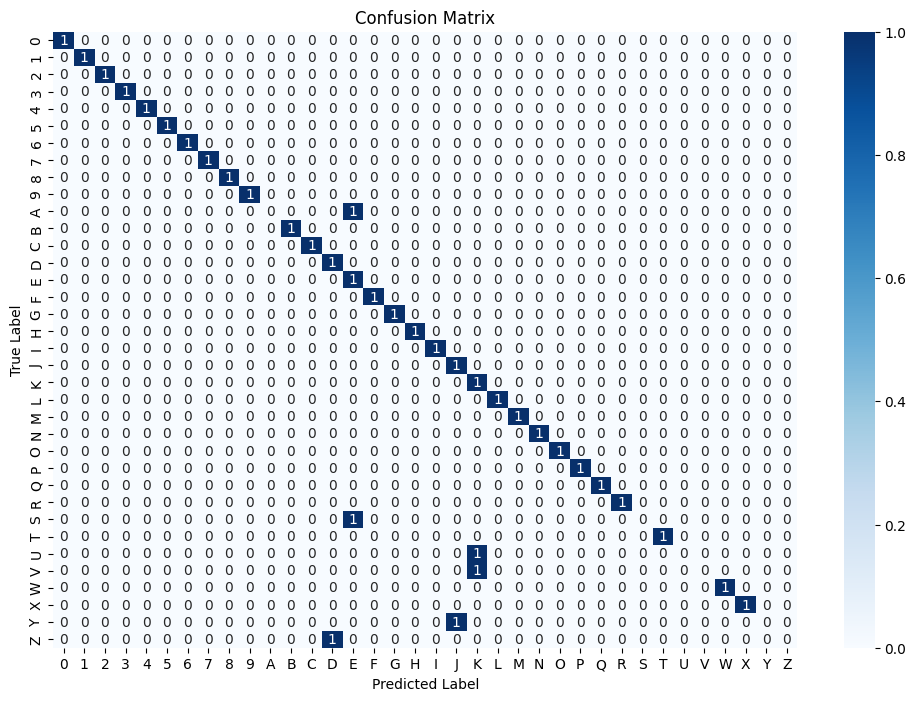

In [ ]:
# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

**Inference**:
 * **Diagonal Dominance**: Most of the predictions are correctly classified, as seen from the dominant diagonal line with values 1. This suggests the model performs well in distinguishing between different ASL letters/numbers.

 * **Few Misclassifications**: There are some off-diagonal entries (nonzero values outside the diagonal), indicating misclassifications.
 
 * **Potential Confusion Pairs**: Some misclassifications might indicate similar-looking ASL gestures (e.g., "U", "V" wrongly predicted as "K", or "Y" wrongly predicted as "J").

Taking the example of U and V misclassified as K

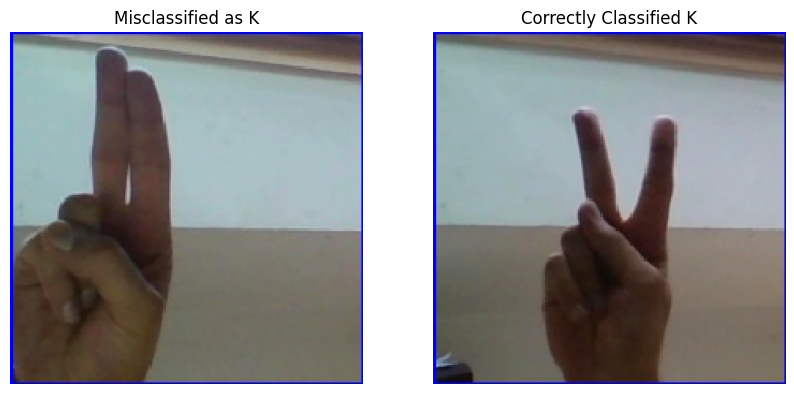

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Extract indices of misclassified U and V as K
misclassified_indices = []
k_correct_indices = []

for i, (true_label, pred_label) in enumerate(zip(y_true, y_pred_classes)):
    if (true_label in [train_generator.class_indices['U'], train_generator.class_indices['V']]) and pred_label == train_generator.class_indices['K']:
        misclassified_indices.append(i)
    elif true_label == train_generator.class_indices['K'] and pred_label == train_generator.class_indices['K']:
        k_correct_indices.append(i)

# Select one example from each
misclassified_u_v_index = misclassified_indices[0] if misclassified_indices else None
correct_k_index = k_correct_indices[0] if k_correct_indices else None

# Load images
if misclassified_u_v_index is not None and correct_k_index is not None:
    misclassified_u_v_img = test_generator.filepaths[misclassified_u_v_index]
    correct_k_img = test_generator.filepaths[correct_k_index]

    # Display Images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Misclassified Image
    img1 = load_img(misclassified_u_v_img, target_size=img_size)
    axes[0].imshow(img1)
    axes[0].set_title("Misclassified as K")
    axes[0].axis('off')
    
    # Correct K Image
    img2 = load_img(correct_k_img, target_size=img_size)
    axes[1].imshow(img2)
    axes[1].set_title("Correctly Classified K")
    axes[1].axis('off')
    
    plt.show()
else:
    print("No misclassified images found for U or V as K.")

In [ ]:
import numpy as np
import os

# Get class label mappings
class_indices = test_generator.class_indices
label_map = {v: k for k, v in class_indices.items()}  # Reverse mapping

# True labels and predictions
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Find misclassified indices
misclassified_U_as_K = np.where((y_true == class_indices["U"]) & (y_pred_classes == class_indices["K"]))[0]
misclassified_V_as_K = np.where((y_true == class_indices["V"]) & (y_pred_classes == class_indices["K"]))[0]
correctly_classified_K = np.where((y_true == class_indices["K"]) & (y_pred_classes == class_indices["K"]))[0]

# Get filenames to identify images
filenames = test_generator.filenames

# Get filenames of misclassified and correctly classified images
misclassified_U_file = filenames[misclassified_U_as_K[0]] if len(misclassified_U_as_K) > 0 else None
misclassified_V_file = filenames[misclassified_V_as_K[0]] if len(misclassified_V_as_K) > 0 else None
correct_K_file = filenames[correctly_classified_K[0]] if len(correctly_classified_K) > 0 else None

# Construct full image paths
base_dir = test_generator.directory  # Base directory where test images are stored
misclassified_U_img_path = f"{base_dir}/{misclassified_U_file}" if misclassified_U_file else None
misclassified_V_img_path = f"{base_dir}/{misclassified_V_file}" if misclassified_V_file else None
correct_K_img_path = f"{base_dir}/{correct_K_file}" if correct_K_file else None

# Collect valid image paths
image_paths = [p for p in [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path] if p is not None]
labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"][:len(image_paths)]

# Function to load images safely
def load_image_from_path(img_path):
    return load_img(img_path) if img_path and os.path.exists(img_path) else None

# Load images using the corrected function calls
misclassified_U_img = load_image_from_path(misclassified_U_img_path)
misclassified_V_img = load_image_from_path(misclassified_V_img_path)
correct_K_img = load_image_from_path(correct_K_img_path)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


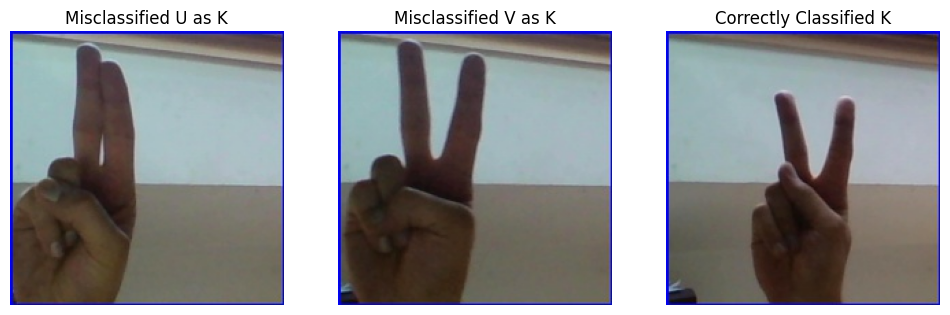

In [ ]:
import matplotlib.pyplot as plt

# Function to load and display images
def display_images(image_files, titles):
    plt.figure(figsize=(12, 4))
    for i, img_file in enumerate(image_files):
        if img_file is not None:
            img_path = test_generator.directory + "/" + img_file  # Full path
            img = plt.imread(img_path)
            plt.subplot(1, len(image_files), i + 1)
            plt.imshow(img)
            plt.title(titles[i])
            plt.axis("off")
    plt.show()

# Display the images
display_images(
    [misclassified_U_file, misclassified_V_file, correct_K_file],
    ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"]
)

Grad-CAM

**Grad-CAM**

Grad-CAM highlights which parts of the image influenced the model's decision. This is useful for understanding why the model classified an image as a specific ASL sign.

 What this does:

 * Extracts gradients from the last conv layer

 * Generates a heatmap highlighting important regions

 * Overlays the heatmap on the original image


 Visualization Type: Heatmap overlay

In [56]:
# Fetch actual images from test_generator using indices
images = []
for idx in [30, 31, 20]:  # Replace with the actual indices of misclassified images
    batch_index = idx // test_generator.batch_size  # Find batch index
    batch_offset = idx % test_generator.batch_size  # Find position in batch
    
    test_generator.reset()  # Ensure generator starts fresh
    for i in range(batch_index + 1):  # Iterate to the required batch
        batch_images, _ = next(test_generator)  # Correct method to get next batch
    
    images.append(batch_images[batch_offset])  # Extract image from batch

# Convert images to NumPy arrays and check their shape
images = np.array(images)
print("Extracted Image Shapes:", [img.shape for img in images])  # Should be [(224, 224, 3), ...]

Extracted Image Shapes: [(224, 224, 3), (224, 224, 3), (224, 224, 3)]


Image 0 Shape: (224, 224, 3)
Image 1 Shape: (224, 224, 3)
Image 2 Shape: (224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step


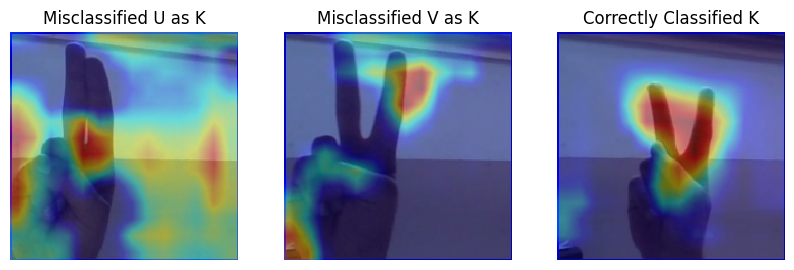

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# # Function to load image from path
# def load_image_from_path(img_file, base_dir, target_size=(224, 224)):
#     """Loads an image from a given filename and directory."""
#     if img_file is None:
#         return None
#     img_path = f"{base_dir}/{img_file}"
#     img = image.load_img(img_path, target_size=target_size)  # Load image
#     img_array = image.img_to_array(img) / 255.0  # Convert to array & normalize
#     return img_array

# # Load images from filenames
# base_dir = test_generator.directory  # Base directory where images are stored
# misclassified_U_img = load_image_from_path(misclassified_U_file, base_dir)
# misclassified_V_img = load_image_from_path(misclassified_V_file, base_dir)
# correct_K_img = load_image_from_path(correct_K_file, base_dir)

# Store images in a list (filter None values)
images = [img for img in [misclassified_U_img, misclassified_V_img, correct_K_img] if img is not None]
labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"][: len(images)]

# Check if images loaded correctly
for i, img in enumerate(images):
    print(f"Image {i} Shape: {img.shape}")

# Ensure images are expanded properly for model input
images = [np.expand_dims(img, axis=0) for img in images]

# Function to compute Grad-CAM heatmap
def get_grad_cam(model, img_array, class_idx, layer_name):
    """Computes Grad-CAM heatmap for an image and model."""
    grad_model = Model(inputs=model.input, outputs=[model.get_layer(layer_name).output, model.output])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_idx]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    
    heatmap = np.maximum(heatmap, 0)  # Apply ReLU

    # **Ensure proper normalization**
    if np.max(heatmap) != 0:  # Avoid division by zero
        heatmap /= np.max(heatmap)  
    
    return heatmap

def overlay_heatmap(img, heatmap, alpha=0.4):
    """Overlays a heatmap onto an image."""
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    # **Use reversed colormap**
    heatmap = cv2.applyColorMap(255 - heatmap, cv2.COLORMAP_JET)
    
    overlayed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return overlayed_img

# Plot Grad-CAM results
def plot_grad_cam(model, images, labels, layer_name):
    plt.figure(figsize=(10, 5))
    
    for i, (img, label) in enumerate(zip(images, labels)):
        class_idx = np.argmax(model.predict(img))  # Predicted class
        heatmap = get_grad_cam(model, img, class_idx, layer_name)
        
        # Remove batch dimension for visualization
        img = np.squeeze(img)  
        overlayed_img = overlay_heatmap((img * 255).astype(np.uint8), heatmap)
        
        plt.subplot(1, len(images), i + 1)
        plt.imshow(overlayed_img)
        plt.title(label)
        plt.axis("off")
    
    plt.show()

# Run Grad-CAM visualization
layer_name = "block5_conv3"  # Last convolutional layer of MobileNetV2
plot_grad_cam(model, images, labels, layer_name)

LIME

**LIME**

LIME perturbs the image slightly to see how the model's predictions change.

Divides image into superpixels (meaningful chunks). Randomly removes superpixels and checks how the model’s prediction changes.And important regions are the ones which have strong impact on prediction. Helps explain what parts of the image the model relies on for classification.

Visualization Type: Boundary-based explanation.

In [ ]:
pip install lime

In [ ]:
# # Construct full image paths
# base_dir = test_generator.directory  # Base directory where test images are stored
# misclassified_U_img_path = f"{base_dir}/{misclassified_U_file}" if misclassified_U_file else None
# misclassified_V_img_path = f"{base_dir}/{misclassified_V_file}" if misclassified_V_file else None
# correct_K_img_path = f"{base_dir}/{correct_K_file}" if correct_K_file else None

# # Collect valid image paths
# image_paths = [p for p in [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path] if p is not None]
# labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"][:len(image_paths)]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load and preprocess image
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = load_img(img_path, target_size=target_size)  # Load image
    img_array = img_to_array(img) / 255.0  # Normalize
    return img_array

# Function to get model predictions for LIME
def predict_fn(images):
    return model.predict(np.array(images))  # Model must return probabilities

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


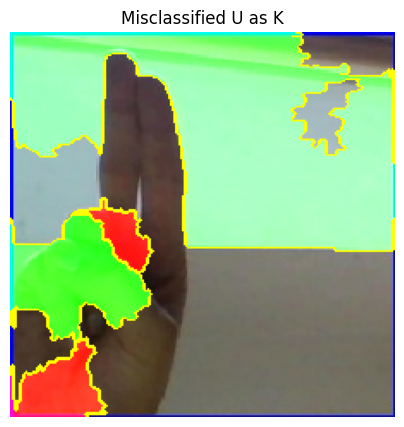

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


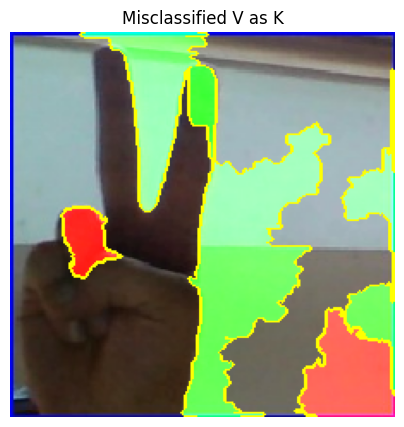

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


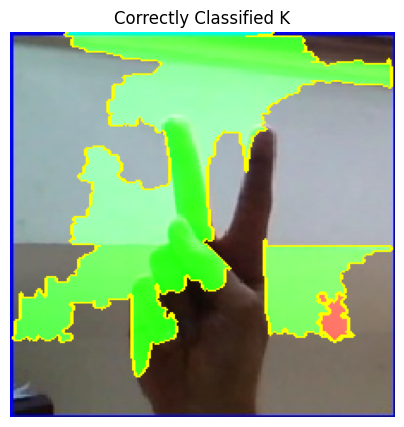

In [ ]:
# LIME Explanation
def apply_lime_explanation(img_path, label, top_labels=5):
    img_array = load_and_preprocess_image(img_path)
    explainer = lime_image.LimeImageExplainer()
    
    explanation = explainer.explain_instance(
        img_array,
        predict_fn,
        top_labels=top_labels,
        hide_color=0,
        num_samples=100  # More samples = better approximation
    )
    
    # Visualize Explanation
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
    
    plt.figure(figsize=(5, 5))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(label)
    plt.axis("off")
    plt.show()

# Apply LIME to U, V, and K images
for img_path, label in zip(image_paths, labels):
    apply_lime_explanation(img_path, label)

* Green regions highlight areas that positively contribute to the model's decision. These are the most important features for classification.

* Red regions indicate areas that negatively contribute, meaning they push the model away from its predicted class.

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


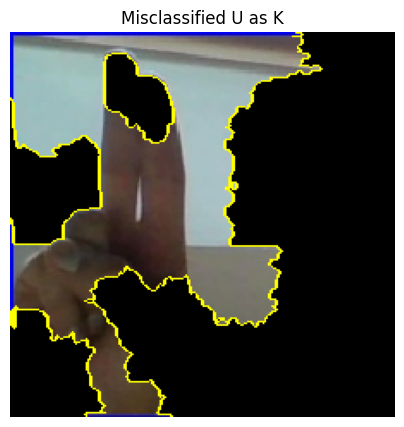

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


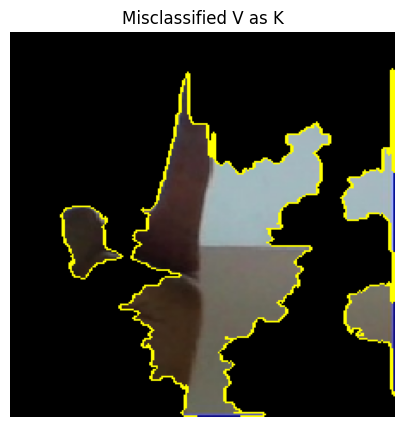

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


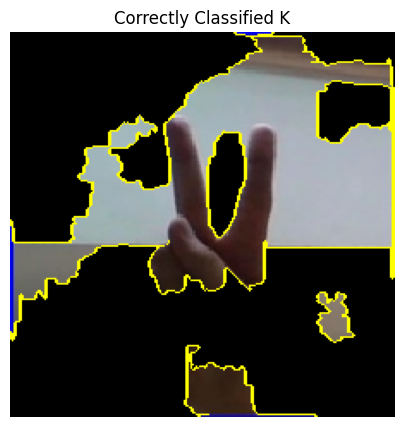

In [87]:
# LIME Explanation
def apply_lime_explanation(img_path, label, top_labels=5):
    img_array = load_and_preprocess_image(img_path)
    explainer = lime_image.LimeImageExplainer()
    
    explanation = explainer.explain_instance(
        img_array,
        predict_fn,
        top_labels=top_labels,
        hide_color=0,
        num_samples=100  # More samples = better approximation
    )
    
    # Visualize Explanation
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=True
    )
    
    plt.figure(figsize=(5, 5))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(label)
    plt.axis("off")
    plt.show()

# Apply LIME to U, V, and K images
for img_path, label in zip(image_paths, labels):
    apply_lime_explanation(img_path, label)

Occlusion Sensitivity

* Algorithm: Divide the image into small patches. Cover (occlude) a patch by replacing it with a solid color (e.g., black or gray). Pass the modified image to the model and check how the prediction confidence changes. Repeat for all patches and record how each occlusion affects the prediction. Generate a heatmap where red areas indicate regions that significantly impact the classification (high importance), and blue areas show regions with little to no effect.

* If occluding a part drops the confidence, that region is important for classification.

* If occluding a part has no effect, that region is not contributing much to the decision.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

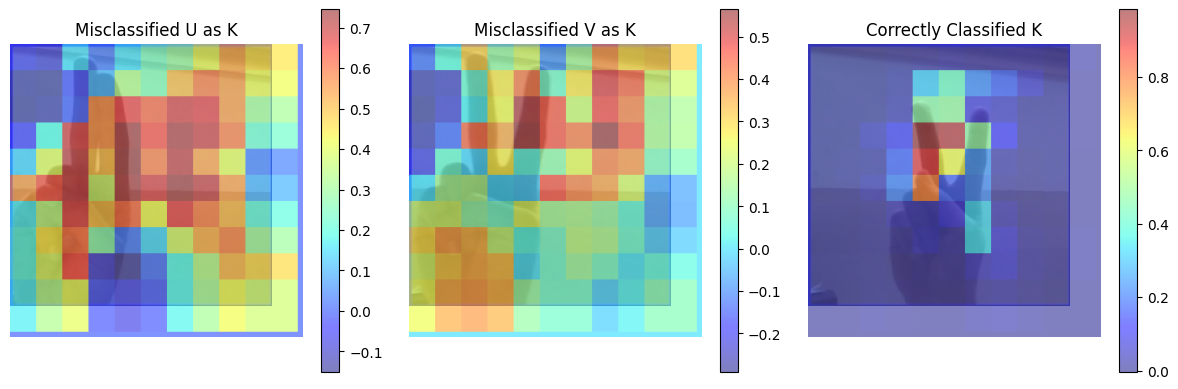

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os

# Function to apply occlusion sensitivity
def occlusion_sensitivity(image_path, model, class_index, patch_size=40, stride=20):
    if not os.path.exists(image_path):
        print(f"Error: File not found - {image_path}")
        return None  # Skip if image not found
    
    image = load_and_preprocess_image(image_path)
    image_height, image_width, _ = image.shape
    heatmap = np.zeros((image_height, image_width))

    original_prediction = model.predict(np.expand_dims(image, axis=0))[0][class_index]

    for y in range(0, image_height - patch_size, stride):
        for x in range(0, image_width - patch_size, stride):
            occluded_image = image.copy()
            occluded_image[y:y + patch_size, x:x + patch_size, :] = 0  # Black Patch
            
            pred = model.predict(np.expand_dims(occluded_image, axis=0))[0][class_index]
            heatmap[y:y + patch_size, x:x + patch_size] = original_prediction - pred  

    return heatmap

# Define valid image paths and labels
image_paths = [p for p in [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path] if p]
labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"][:len(image_paths)]
class_index = class_indices["K"]  # Target class

# Plot results for all images
plt.figure(figsize=(12, 4))
for i, (img_path, label) in enumerate(zip(image_paths, labels)):
    heatmap = occlusion_sensitivity(img_path, model, class_index)
    
    if heatmap is None:
        continue  # Skip if no heatmap generated
    
    plt.subplot(1, len(image_paths), i+1)
    plt.imshow(load_img(img_path), alpha=0.6)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(label)
    plt.axis("off")
    plt.colorbar()

plt.tight_layout()
plt.show()


**Inference**

1) Misclassified "U" as "K" (Left Image)
* The red and yellow regions highlight areas that, when occluded, significantly change the model’s confidence in classifying "K".

* The cross-pattern focus suggests that the model might be looking at a combination of fingers and palm region.

* The dark blue regions (low impact) indicate areas that do not contribute significantly to classification.

2)  Misclassified "V" as "K" (Middle Image)
* The finger regions are again highlighted in red/yellow, showing their importance.

* Distributed importance suggests the model may be looking at multiple hand features instead of focusing on a single distinguishing pattern.

* The blue and cyan areas suggest parts that are not critical for classification.

3) Correctly Classified "K" (Right Image)
* The intense red on the fingers indicates the model strongly relies on the "K" sign’s hand shape.

* The rest of the image is dark blue, meaning non-finger regions do not influence the classification.

* The heatmap suggests the model is confident and selective in detecting the "K" sign correctly.

**Integrated Gradients (IG)**

Choose a Baseline Image (usually a black or blurred version of the original image). Create a Path from the baseline to the original image by gradually increasing pixel intensity. Compute Gradients at each step to measure how changes in pixel values affect the model’s output. Integrate (Sum) the Gradients over the path to get the total importance of each pixel.

Unlike Grad-CAM, IG is class-independent and doesn’t rely on feature maps.

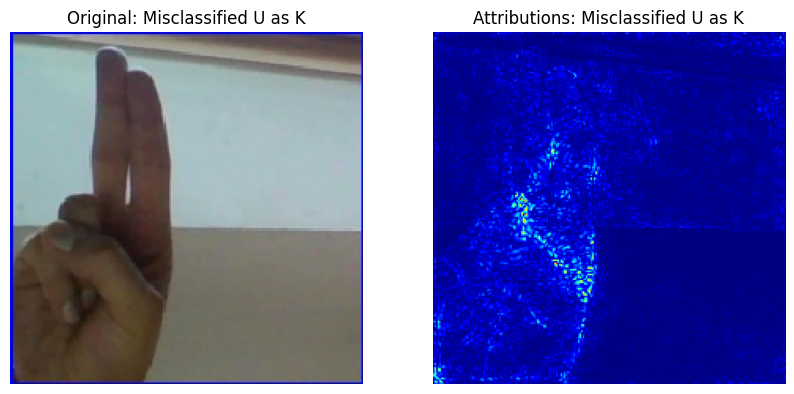

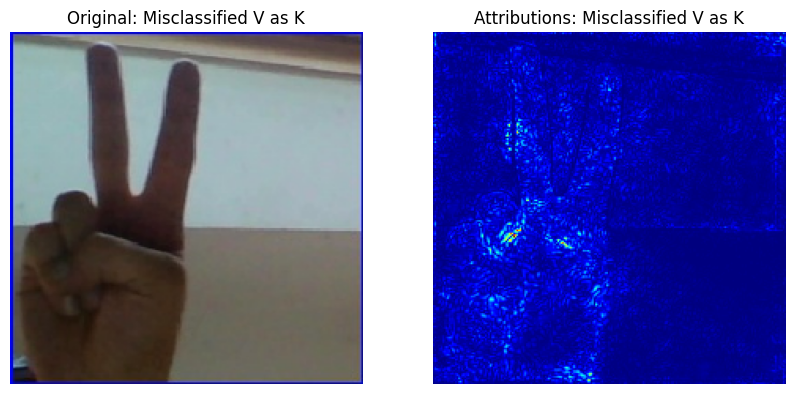

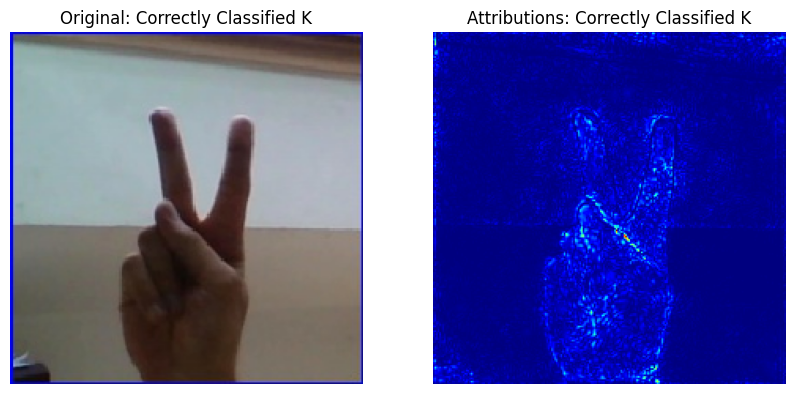

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Function to compute Integrated Gradients
def integrated_gradients(model, img_array, baseline=None, steps=50, target_class=None):
    if baseline is None:
        baseline = np.zeros_like(img_array)  # Default to a black image
    
    # Generate interpolated images
    interpolated_images = [
        baseline + (float(i) / steps) * (img_array - baseline) for i in range(steps + 1)
    ]
    interpolated_images = tf.convert_to_tensor(interpolated_images, dtype=tf.float32)

    # Remove extra batch dimension if necessary
    interpolated_images = tf.squeeze(interpolated_images, axis=1)  # Ensure shape is (steps+1, 224, 224, 3)

    # Ensure target_class is an integer
    target_class = int(target_class)

    # Compute gradients for each interpolated image
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images)
        target_output = predictions[:, target_class]  # Get probability of the target class

    # Compute gradients
    grads = tape.gradient(target_output, interpolated_images)

    # Average gradients and multiply by input difference
    avg_grads = tf.reduce_mean(grads, axis=0)  # Use TensorFlow mean instead of NumPy
    attributions = (img_array - baseline) * avg_grads

    return attributions.numpy()  # Convert to NumPy for further processing

# Load and preprocess image
def preprocess_image(image_path):
    if image_path is None:
        return None
    img = load_img(image_path, target_size=(224, 224))  # Resize to MobileNetV2 input size
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Normalize image
    return img_array

# Visualize Attributions
def plot_attributions(img_path, attributions, title):
    if img_path is None:
        print(f"Skipping {title} as no image was found.")
        return
    
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0  # Normalize for display
    
    # Normalize attributions for visualization
    attributions = np.sum(np.abs(attributions), axis=-1)  # Aggregate across color channels
    attributions = (attributions - attributions.min()) / (attributions.max() - attributions.min() + np.finfo(np.float32).eps)  # Normalize safely

    # Remove batch dimension (Fix the error)
    if attributions.ndim == 3:  # Shape is (1, 224, 224)
        attributions = attributions[0]  # Remove batch dimension

    # Plot original image and attributions
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {title}")
    ax[0].axis("off")

    ax[1].imshow(attributions, cmap="jet")  # Fixed!
    ax[1].set_title(f"Attributions: {title}")
    ax[1].axis("off")

    plt.show()

# Image paths and labels
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
image_labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"]
target_classes = [class_indices["K"], class_indices["K"], class_indices["K"]]  # All predictions are for "K"

# Apply IG to each image
for img_path, label, target_class in zip(image_paths, image_labels, target_classes):
    img_array = preprocess_image(img_path)
    if img_array is not None:
        attributions = integrated_gradients(model, img_array, steps=50, target_class=target_class)
        plot_attributions(img_path, attributions, label)

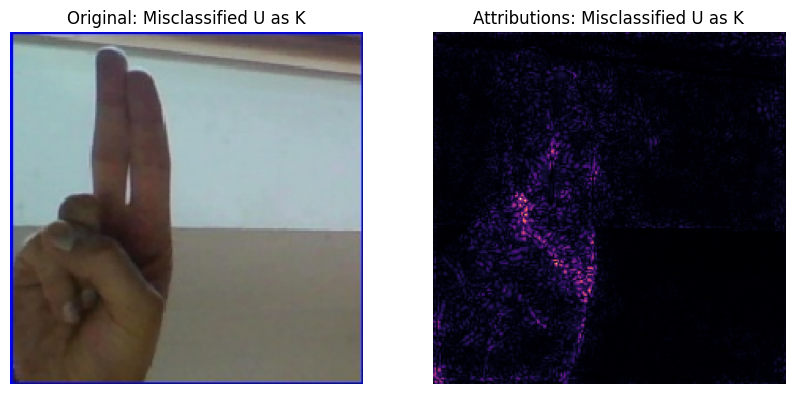

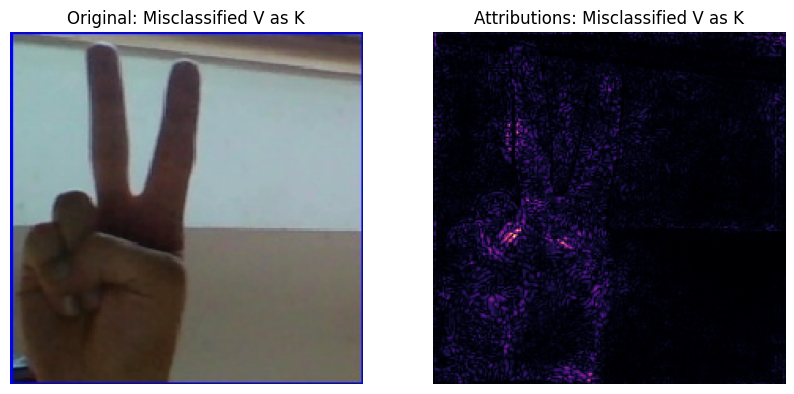

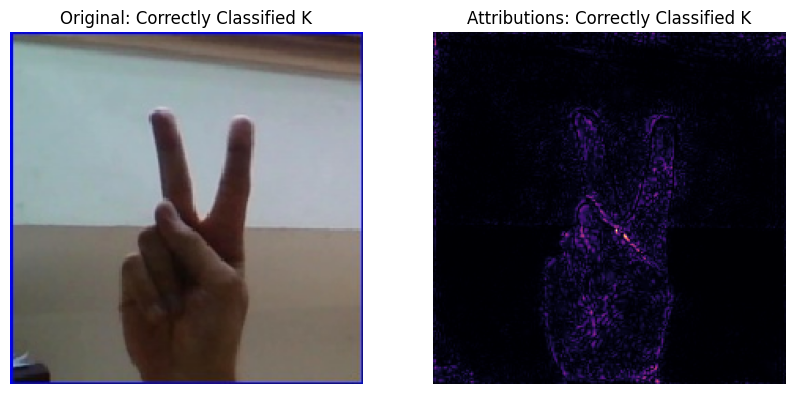

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Function to compute Integrated Gradients
def integrated_gradients(model, img_array, baseline=None, steps=50, target_class=None):
    if baseline is None:
        baseline = np.zeros_like(img_array)  # Default to a black image

    # Generate interpolated images
    interpolated_images = tf.stack(
        [baseline + (float(i) / steps) * (img_array - baseline) for i in range(steps + 1)]
    )  # Ensure correct shape (steps+1, 224, 224, 3)

    interpolated_images = tf.squeeze(interpolated_images, axis=1)  # Remove extra batch dimension if present

    # Ensure target_class is an integer
    target_class = int(target_class)

    # Compute gradients for each interpolated image
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images)
        target_output = predictions[:, target_class]  # Get probability of the target class

    # Compute gradients
    grads = tape.gradient(target_output, interpolated_images)

    # Average gradients and multiply by input difference
    avg_grads = tf.reduce_mean(grads, axis=0)  # Use TensorFlow mean instead of NumPy
    attributions = (img_array - baseline) * avg_grads

    return attributions.numpy()  # Convert to NumPy for further processing

# Load and preprocess image
def preprocess_image(image_path):
    if image_path is None:
        return None
    img = load_img(image_path, target_size=(224, 224))  # Resize to MobileNetV2 input size
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Normalize image
    return img_array

# Improved visualization with contrast normalization
# Visualize Attributions
def plot_attributions(img_path, attributions, title):
    if img_path is None:
        print(f"Skipping {title} as no image was found.")
        return
    
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0  # Normalize for display
    
    # Normalize attributions for visualization
    attributions = np.sum(np.abs(attributions), axis=-1)  # Aggregate across color channels
    
    # Ensure attributions have the correct shape (224, 224)
    if attributions.ndim == 3:  # Shape is (1, 224, 224)
        attributions = np.squeeze(attributions, axis=0)  # Remove batch dimension

    # Normalize attributions for better visualization
    attributions = (attributions - attributions.min()) / (attributions.max() - attributions.min() + np.finfo(np.float32).eps)

    # Plot original image and attributions
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {title}")
    ax[0].axis("off")

    ax[1].imshow(attributions, cmap="magma")  # Fixed!
    ax[1].set_title(f"Attributions: {title}")
    ax[1].axis("off")

    plt.show()

# Image paths and labels
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
image_labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"]
target_classes = [class_indices["K"], class_indices["K"], class_indices["K"]]  # All predictions are for "K"

# Apply IG to each image
for img_path, label, target_class in zip(image_paths, image_labels, target_classes):
    img_array = preprocess_image(img_path)
    if img_array is not None:
        attributions = integrated_gradients(model, img_array, steps=100, target_class=target_class)  # Increased steps
        plot_attributions(img_path, attributions, label)

**Inference from Integrated Gradients Visualizations**
1) Misclassified "U" as "K"

    * The attribution heatmap highlights certain areas of the hand that contributed to the misclassification.

    * The focus is on the fingers, suggesting that the model might be confused by the relative positioning of the index and middle fingers.

    * Some attributions appear in the background, indicating possible noise affecting the decision.

2) Misclassified "V" as "K"

    * Similar patterns are visible, with attributions concentrated around the fingers.

    * This suggests that the model relies on certain key structures of the hand but struggles to differentiate between "V" and "K".

    * The lower part of the image shows some unexplained attributions, possibly indicating reliance on background features.

3) Correctly Classified "K"

    * The attributions are primarily focused on the hand, especially the fingers.

    * This suggests that the model correctly learned the key features for "K".

    * Less attribution is given to background areas, indicating a more focused classification.



**LRP**

LRP explains why a neural network made a certain decision by tracing back the contributions of each neuron from the output to the input pixels.

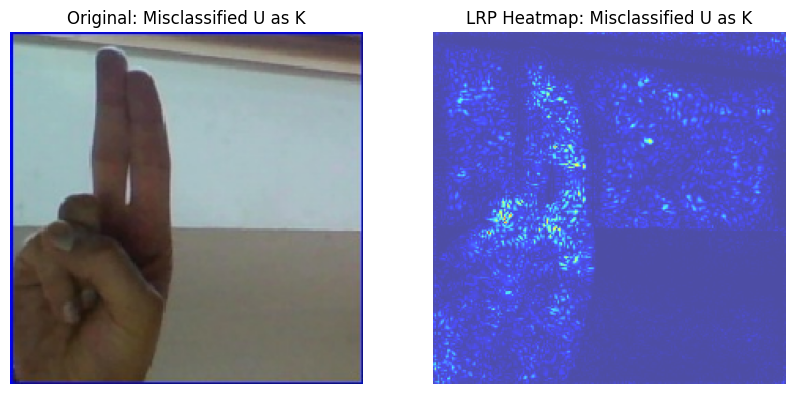

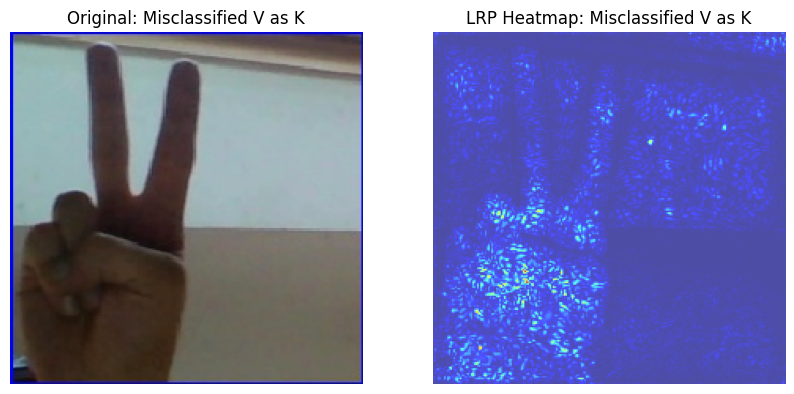

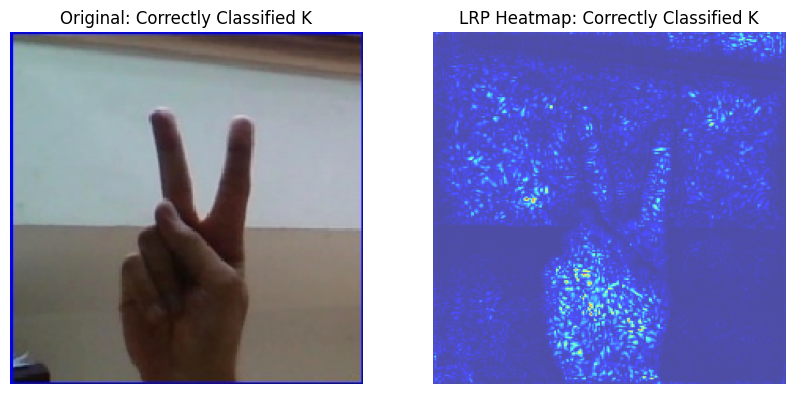

In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load pre-trained VGG-16 model
model = VGG16(weights="imagenet")

# Function to compute LRP (Layer-wise Relevance Propagation)
def compute_lrp(model, img_array, target_class):
    with tf.GradientTape() as tape:
        img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
        tape.watch(img_array)
        predictions = model(img_array)
        target_output = predictions[:, target_class]
    
    gradients = tape.gradient(target_output, img_array)
    relevance = gradients * img_array  # Simple LRP approximation
    return relevance.numpy()

# Preprocess image function
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)
    return img_array

# Visualize function
def plot_lrp(img_path, relevance, title):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0  # Normalize for display
    
    relevance = np.sum(np.abs(relevance), axis=-1)[0]  # Aggregate channels
    relevance = (relevance - relevance.min()) / (relevance.max() - relevance.min() + 1e-5)  # Normalize
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {title}")
    ax[0].axis("off")
    
    ax[1].imshow(relevance, cmap="jet", alpha=0.7)
    ax[1].set_title(f"LRP Heatmap: {title}")
    ax[1].axis("off")
    
    plt.show()

# Image paths and labels (Replace these with actual paths)
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
image_labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"]
target_classes = [class_indices["K"], class_indices["K"], class_indices["K"]]

# Apply LRP to each image
for img_path, label, target_class in zip(image_paths, image_labels, target_classes):
    img_array = preprocess_image(img_path)
    if img_array is not None:
        relevance = compute_lrp(model, img_array, target_class)
        plot_lrp(img_path, relevance, label)

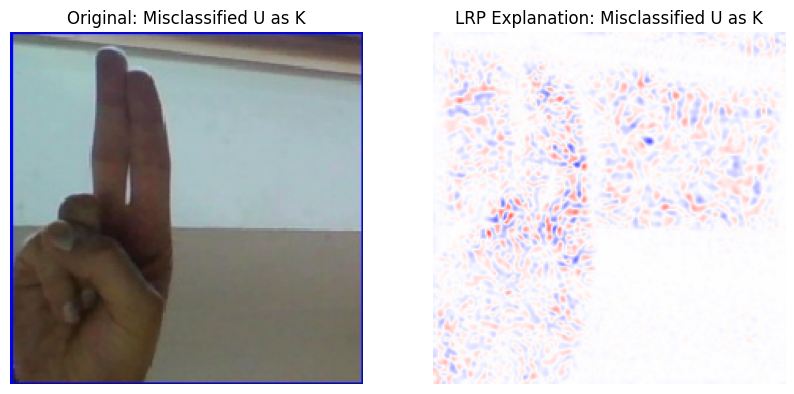

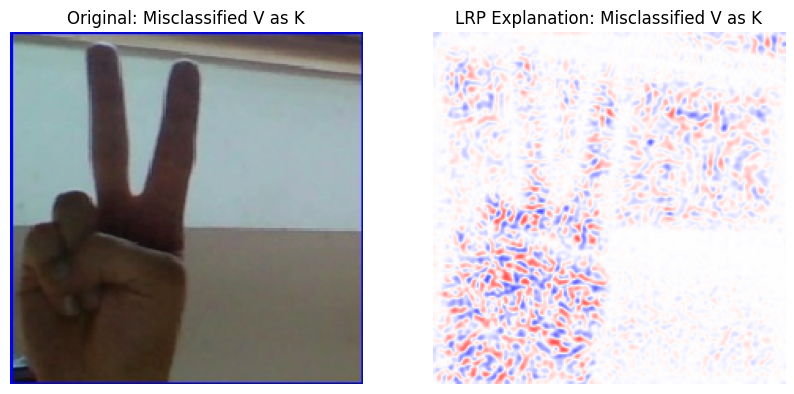

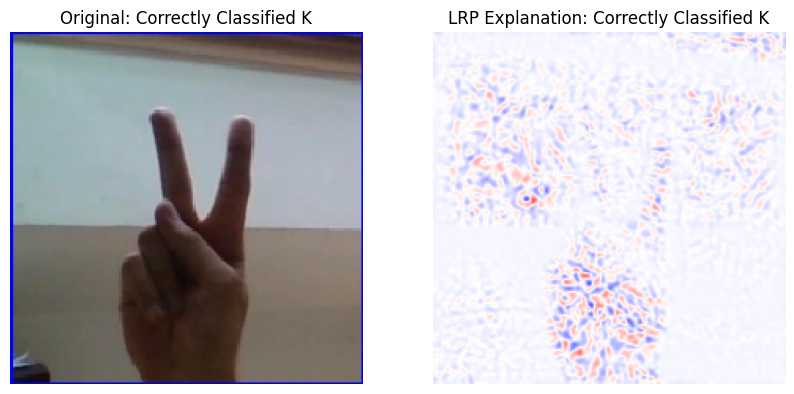

In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2

# Load pre-trained VGG-16 model
model = VGG16(weights="imagenet")

# Function to compute LRP (Layer-wise Relevance Propagation)
def compute_lrp(model, img_array, target_class):
    with tf.GradientTape() as tape:
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        target_output = predictions[:, target_class]
    
    gradients = tape.gradient(target_output, img_tensor)
    relevance = gradients * img_tensor  # Simple LRP approximation
    return relevance.numpy()

# Preprocess image function
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)
    return img_array

SCALE_FACTOR = 100 # Adjust between 10-50 for better visualization

# Visualize function with red-blue (bwr) colormap
def plot_lrp(img_path, relevance, title):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0  # Normalize for display
    
    relevance = np.sum(relevance, axis=-1)[0]  # Aggregate channels

    # Apply absolute scaling
    relevance = relevance / (np.max(np.abs(relevance)) + 1e-5)
    
    # Enhance contrast
    relevance = np.clip(relevance * SCALE_FACTOR, -1, 1)

    # Apply Gaussian blur to smoothen visualization
    relevance = cv2.GaussianBlur(relevance, (5, 5), 0)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {title}")
    ax[0].axis("off")
    
    ax[1].imshow(relevance, cmap="bwr", alpha=0.7)
    ax[1].set_title(f"LRP Explanation: {title}")
    ax[1].axis("off")
    
    plt.show()

# Image paths and labels (Replace these with actual paths)
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
image_labels = ["Misclassified U as K", "Misclassified V as K", "Correctly Classified K"]
target_classes = [class_indices["K"], class_indices["K"], class_indices["K"]]

# Apply LRP to each image
for img_path, label, target_class in zip(image_paths, image_labels, target_classes):
    img_array = preprocess_image(img_path)
    if img_array is not None:
        relevance = compute_lrp(model, img_array, target_class)
        plot_lrp(img_path, relevance, label)

CRP

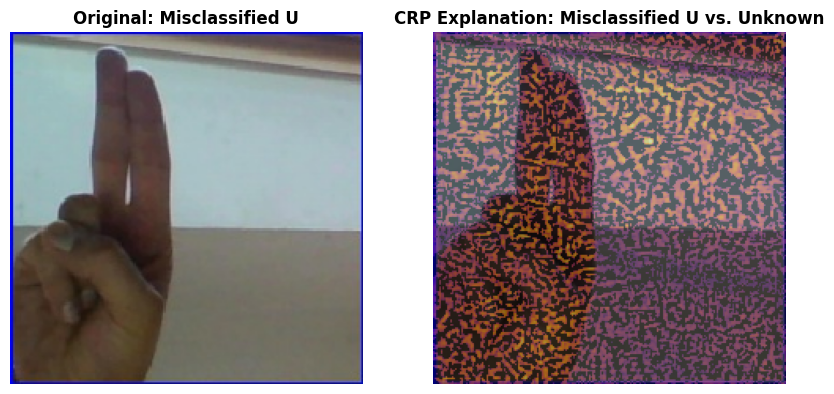

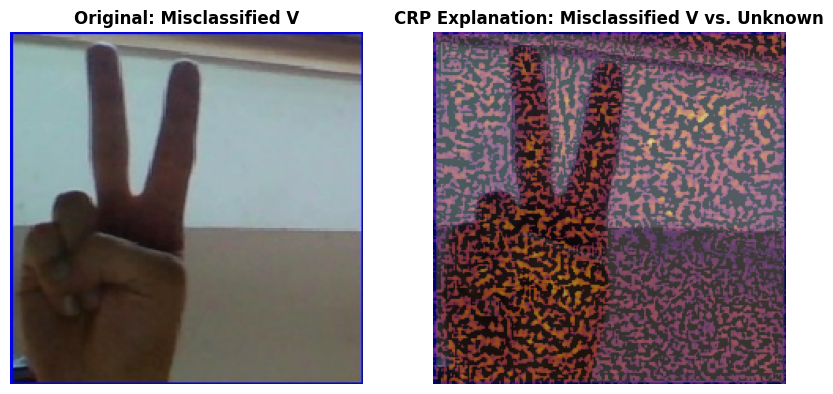

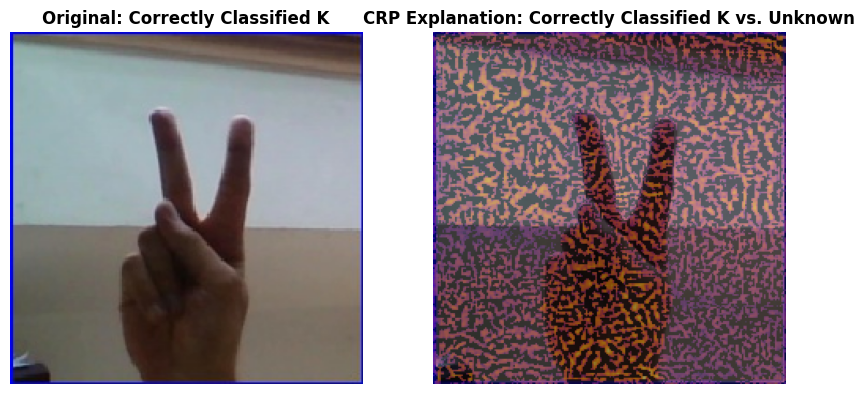

In [56]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# **🔹 Load the Pre-trained Model**
model = VGG16(weights="imagenet")

# **🔹 CRP Function**
def compute_crp(model, img_array, true_class):
    with tf.GradientTape() as tape:
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        
        # Get the predicted class (incorrect class in case of misclassification)
        predicted_class = tf.argmax(predictions[0]).numpy()
        incorrect_class = predicted_class if predicted_class != true_class else None

        # Compute gradients w.r.t. the **incorrect class**
        target_output = predictions[:, predicted_class]
        gradients = tape.gradient(target_output, img_tensor)
    
    # **🔹 CRP Approximation**
    crp_map = gradients * img_tensor  # Element-wise relevance propagation
    return crp_map.numpy(), incorrect_class

# **🔹 Image Preprocessing**
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)
    return img_array

# **🔹 CRP Visualization**
def plot_crp(img_path, crp_map, true_label, incorrect_label):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img) / 255.0  # Normalize image

    # **🔹 Aggregate and Normalize CRP Map**
    crp_map = np.sum(crp_map, axis=-1)[0]  
    crp_map = np.maximum(crp_map, 0)  # Keep only positive relevance

    # **🔹 Stronger Contrast Adjustment**
    crp_map = (crp_map - np.min(crp_map)) / (np.max(crp_map) - np.min(crp_map) + 1e-5)  
    crp_map = np.power(crp_map, 0.2)  # Reduce gamma to amplify differences

    # **🔹 Use 'Inferno' for Better Contrast**
    cmap = plt.get_cmap("inferno")
    crp_map_colored = cmap(crp_map)[:, :, :3]  

    # **🔹 Overlay Heatmap on Image**
    alpha = 0.5  
    overlay = (1 - alpha) * img + alpha * crp_map_colored  

    # **🔹 Plot Results**
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {true_label}", fontsize=12, fontweight='bold')
    ax[0].axis("off")
    
    ax[1].imshow(overlay)
    ax[1].set_title(f"CRP Explanation: {true_label} vs. {incorrect_label}", fontsize=12, fontweight='bold')
    ax[1].axis("off")
    
    plt.show()

# **🔹 Image Paths and Labels**
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
image_labels = ["Misclassified U", "Misclassified V", "Correctly Classified K"]
true_classes = [class_indices["U"], class_indices["V"], class_indices["K"]]

# **🔹 Run CRP for All Images**
for img_path, label, true_class in zip(image_paths, image_labels, true_classes):
    img_array = preprocess_image(img_path)
    if img_array is not None:
        crp_map, incorrect_class = compute_crp(model, img_array, true_class)
        incorrect_label = class_indices_inv.get(incorrect_class, "Unknown") if incorrect_class else "Correct"
        plot_crp(img_path, crp_map, label, incorrect_label)

SHAP

In [ ]:
# !pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.1 MB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.8 MB 1.2 MB/s eta 0:00:02
   -------------- ------------------------- 1.0/2.8 MB 1.2 MB/s eta 0:00:02
   ---------------------- ----------------- 1.6/2.8 MB 1.2 MB/s eta 0:00:02
   ------------------------- -------------- 1.8/2.8 MB 1.2 MB/s eta 0:00:01
   ------------------------- -------------- 1.8/2.8 MB 1.2 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.8 MB 1.2 MB/s eta 0:00:01
   --------------------------------- ------ 2.4/2.8 MB 1.2 MB/s eta 0:00:01
   

In [60]:
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Function to safely load and preprocess an image
def preprocess_image(img_path, target_size=(224, 224)):
    if img_path and os.path.exists(img_path):
        img = cv2.imread(img_path)  # Load with OpenCV
        if img is None:
            print(f"Warning: cv2.imread() failed for {img_path}")
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        img = cv2.resize(img, target_size) / 255.0  # Resize and normalize
        return img
    else:
        print(f"Warning: Image path invalid or does not exist: {img_path}")
        return None

# Load and preprocess images
image_paths = [misclassified_U_img_path, misclassified_V_img_path, correct_K_img_path]
images = [preprocess_image(p) for p in image_paths if p is not None]

# Ensure images are properly loaded
images = [img for img in images if img is not None]
if len(images) == 0:
    raise ValueError("No valid images found for SHAP analysis.")

# Convert list to NumPy array
images = np.array(images).reshape(len(images), 224, 224, 3)  # Ensure correct shape

print("Images loaded successfully!")

Images loaded successfully!


d:\Feby\MTech Amrita\Sem 2\XAI\Project\ASL\asl_env\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
d:\Feby\MTech Amrita\Sem 2\XAI\Project\ASL\asl_env\lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


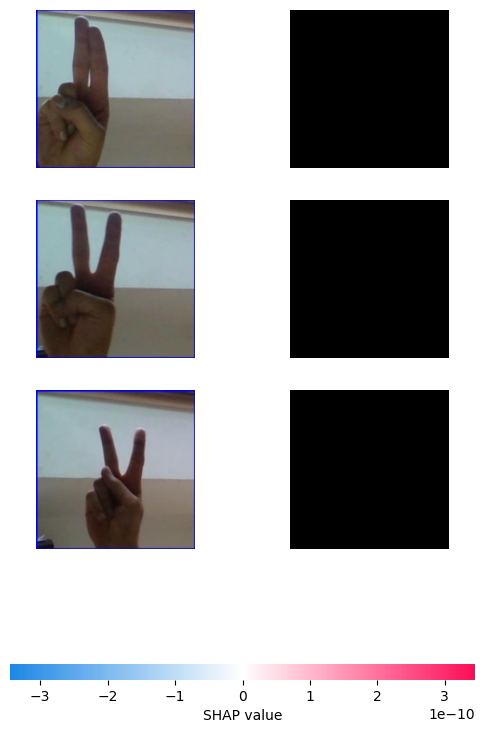

In [62]:
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Use a small subset of images as the background dataset for SHAP
background = images[:10]  # Ensure this contains actual images in (N, 224, 224, 3) format

# Use GradientExplainer 
explainer = shap.GradientExplainer(model, background)

# Get SHAP values for a few test images
shap_values = explainer.shap_values(images[:3])  # Only a few images to keep it efficient

# Visualize SHAP explanations
shap.image_plot(shap_values, images[:3])